In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from skfda.representation.grid import FDataGrid
from skfda.preprocessing.dim_reduction.feature_extraction import FPCA
from sklearn.decomposition import PCA
import gc
import glob  
import pandas as pd
pd.options.mode.copy_on_write = True
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.signal import argrelextrema
import pathos.pools
from functools import partial
import os
import math
from  matplotlib.ticker import PercentFormatter
sns.set_style("white")
# sns.set_context("notebook")
sns.set_theme(style="ticks", palette="husl")
# set dask dashboard
import dask
dask.config.set({'dataframe.query-planning': True})
import dask.dataframe as dd
from scipy.spatial.transform import Rotation as R
# pd.options.mode.chained_assignment = None  # default='warn'
#from dask.distributed import Client
#client = Client()  # start distributed scheduler locally.
#client
import matplotlib.cm as cm
from scipy.stats import t, ttest_rel
from scipy.ndimage import label

from sklearn.preprocessing import StandardScaler
from scipy.linalg import eigh
from scipy.ndimage import gaussian_filter1d
import re
import random
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf
import statsmodels.stats.multitest as smm


event_filter_mult = [   
    'StagEventNew',        
    'FallingRocksEventNew',
    #'FogEventNew',         
    #'MarketPlaceEvent',
    #'CyclistEvent',       
    #'Panne',                  
    #'GhostDriver',
    'MotorcyclistEvent'    ,
]

event_filter_list = event_filter_mult
dir = os.getcwd()
data_path = dir + '/data/'
# Load your specific file 
outlier_features =  ['EyeDirWorldCombined.x', 'NoseVector.x', 'EyeDirWorldCombined.y', 'NoseVector.y', 'SteeringInput']#  , 'EyeDirWorldCombined.z', 'NoseVector.z'     remove as needed
len_outlier_features = len(outlier_features)
event_name = event_filter_list[0]  # e.g., 'FogEventNew'

filepath = data_path + f"/cleaned_data/data_segment/outliers_removed_{len_outlier_features}features/steeringRemoved/segment_around_{event_name}_nearest_neighbor_steeringRemoved.csv" #x 


C:\Users\erene\AppData\Local\Temp\ipykernel_29472\2421284917.py:6: DeprecationWarning: The module "feature_extraction" is deprecated.Please use "dim_reduction" for FPCAor "feature_construction" for feature construction techniques
  from skfda.preprocessing.dim_reduction.feature_extraction import FPCA


# Success * Warning (log)

✅ Combined 3 event files, total rows: 239478

===== PER-EVENT SUCCESS SUMMARY =====
              event_name ExperimentalCondition  n_trials  n_success  \
0   FallingRocksEventNew             AudioOnly        29         14   
1   FallingRocksEventNew         BaseCondition        43         16   
2   FallingRocksEventNew            FullLoopAR        51         33   
3   FallingRocksEventNew               HUDOnly        37         21   
4      MotorcyclistEvent             AudioOnly        29         16   
5      MotorcyclistEvent         BaseCondition        41         16   
6      MotorcyclistEvent            FullLoopAR        51         28   
7      MotorcyclistEvent               HUDOnly        37         25   
8           StagEventNew             AudioOnly        29         15   
9           StagEventNew         BaseCondition        43          8   
10          StagEventNew            FullLoopAR        51         36   
11          StagEventNew               HUDOnly        37        

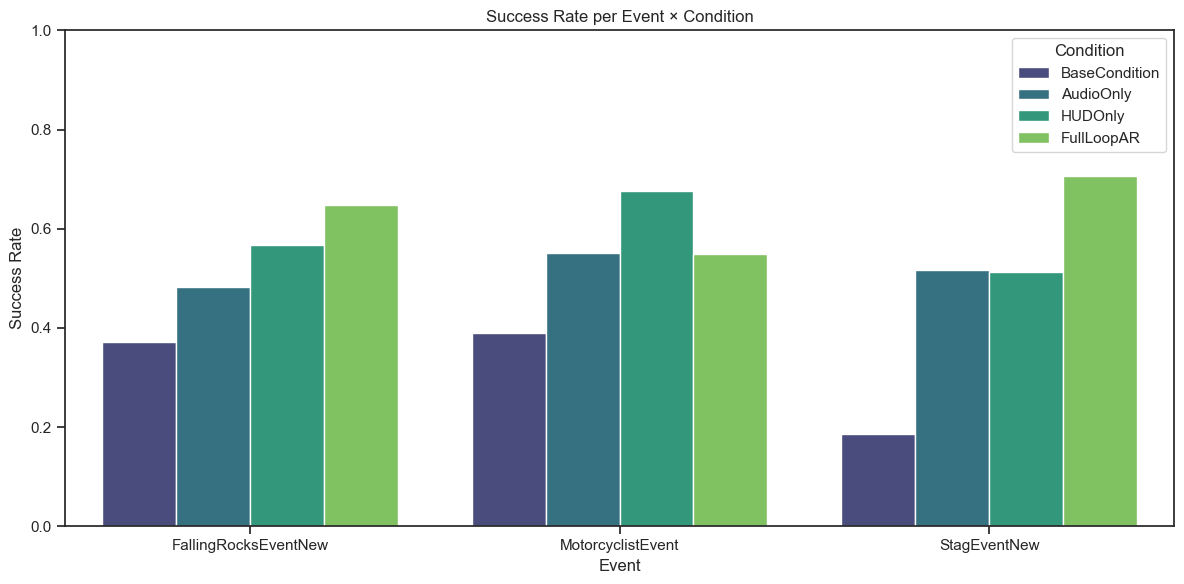

In [2]:


# ------------------ USER SETTINGS ------------------
cond_order = ['BaseCondition','AudioOnly', 'HUDOnly' , 'FullLoopAR']

# ------------------ COMBINE EVENT FILES ------------------
dfs = []
for event_name in event_filter_mult:
    filepath = os.path.join(
        data_path,
        f"cleaned_data/data_segment/outliers_removed_{len_outlier_features}features/"
        f"steeringRemoved/segment_around_{event_name}_nearest_neighbor_steeringRemoved.csv"
    )
    if not os.path.exists(filepath):
        print(f"⚠️ File not found: {filepath}")
        continue
    df_event = pd.read_csv(filepath)
    df_event['event_name'] = event_name
    dfs.append(df_event)

combined_df = pd.concat(dfs, ignore_index=True)
print(f"✅ Combined {len(dfs)} event files, total rows: {len(combined_df)}")

df = combined_df

# ------------------ FILTER TO SELECTED EVENTS ------------------
df_filt = df[df['EventName'].isin(event_filter_mult)].copy()

# ------------------ COMPUTE SUCCESS PER UID × EVENT ------------------
rows = []
for (uid, event), sub in df_filt.groupby(['uid', 'EventName']):
    last100 = sub.tail(100)
    if (last100['SuccessfulCompletionState'] == 1).all():
        success = 1
    elif (last100['SuccessfulCompletionState'] == 0).all():
        success = 0
    else:
        raise ValueError(f"UID {uid}, event {event}: last 100 rows do not match 0/1")
    
    cond = sub['ExperimentalCondition'].iloc[-1]
    rows.append({'uid': uid, 'event_name': event, 'ExperimentalCondition': cond, 'success': success})

success_df = pd.DataFrame(rows)

# ------------------ PER-EVENT SUMMARY ------------------
event_summary = (
    success_df
    .groupby(['event_name', 'ExperimentalCondition'])
    .agg(n_trials=('success','count'),
         n_success=('success','sum'),
         success_rate=('success','mean'))
    .reset_index()
)

# Apply categorical ordering
event_summary['ExperimentalCondition'] = pd.Categorical(
    event_summary['ExperimentalCondition'],
    categories=cond_order,
    ordered=True
)

print("\n===== PER-EVENT SUCCESS SUMMARY =====")
print(event_summary)



# ------------------ PLOTS ------------------
# Per-event plot
plt.figure(figsize=(12,6))
sns.barplot(
    data=event_summary,
    x='event_name',
    y='success_rate',
    hue='ExperimentalCondition',
    hue_order=cond_order,
    palette='viridis'
)
plt.ylabel("Success Rate")
plt.xlabel("Event")
plt.title("Success Rate per Event × Condition")
plt.ylim(0,1)
plt.legend(title="Condition")
plt.tight_layout()
plt.show()


✅ Combined 3 event files, total rows: 239478

=== LOGISTIC REGRESSION (STANDARD) ===
                           Logit Regression Results                           
Dep. Variable:                success   No. Observations:                  478
Model:                          Logit   Df Residuals:                      474
Method:                           MLE   Df Model:                            3
Date:                Mon, 26 Jan 2026   Pseudo R-squ.:                 0.04799
Time:                        15:03:32   Log-Likelihood:                -315.17
converged:                       True   LL-Null:                       -331.06
Covariance Type:            nonrobust   LLR p-value:                 5.844e-07
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                 -0.7770      0.191     -4.0

C:\Users\erene\AppData\Local\Temp\ipykernel_29472\1172951432.py:140: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


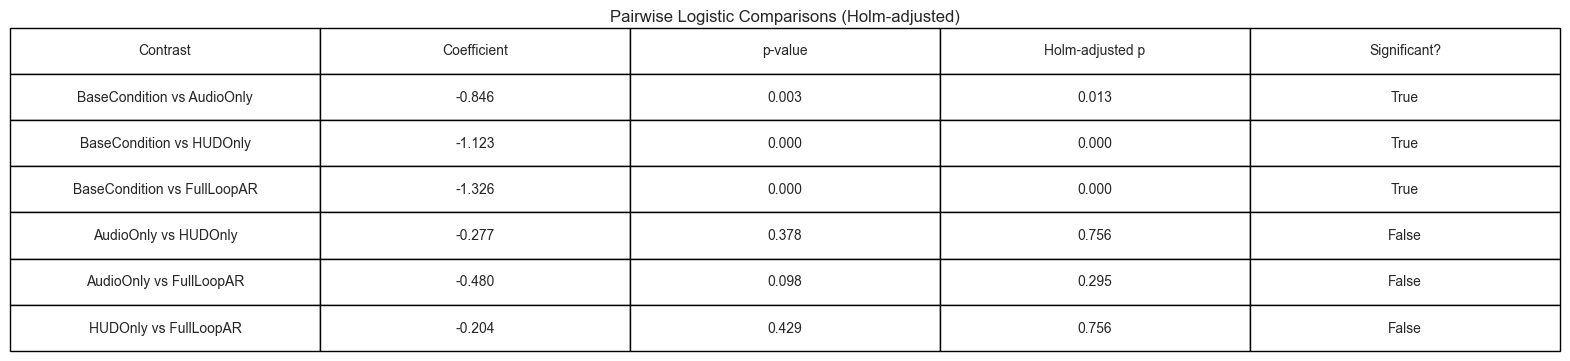

C:\Users\erene\AppData\Local\Temp\ipykernel_29472\1172951432.py:146: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('ExperimentalCondition')


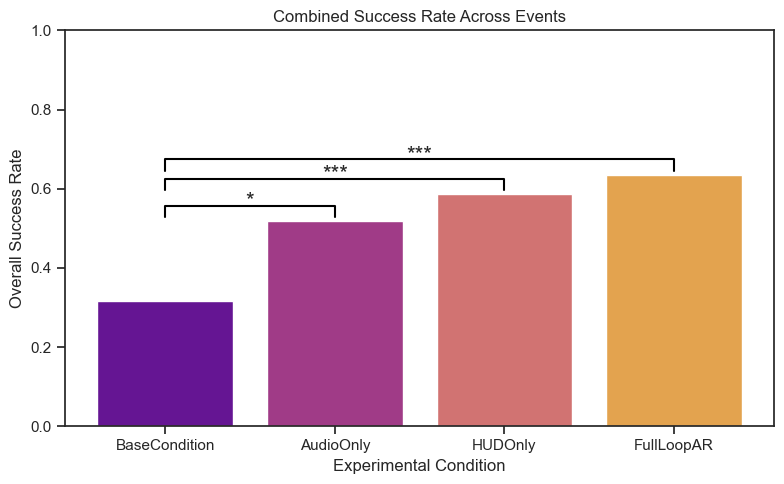

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
import statsmodels.formula.api as smf
import itertools

# ------------------ USER SETTINGS ------------------
cond_order = ['BaseCondition','AudioOnly', 'HUDOnly' , 'FullLoopAR']

# ------------------ COMBINE EVENT FILES ------------------
dfs = []
for event_name in event_filter_mult:
    filepath = os.path.join(
        data_path,
        f"cleaned_data/data_segment/outliers_removed_{len_outlier_features}features/"
        f"steeringRemoved/segment_around_{event_name}_nearest_neighbor_steeringRemoved.csv"
    )
    if not os.path.exists(filepath):
        print(f"⚠️ File not found: {filepath}")
        continue
    df_event = pd.read_csv(filepath)
    df_event['event_name'] = event_name
    dfs.append(df_event)

combined_df = pd.concat(dfs, ignore_index=True)
print(f"✅ Combined {len(dfs)} event files, total rows: {len(combined_df)}")

# ------------------ FILTER TO SELECTED EVENTS ------------------
df_filt = combined_df[combined_df['EventName'].isin(event_filter_mult)].copy()

# ------------------ COMPUTE SUCCESS PER UID × EVENT ------------------
rows = []
for (uid, event), sub in df_filt.groupby(['uid', 'EventName']):
    last100 = sub.tail(100)
    if (last100['SuccessfulCompletionState'] == 1).all():
        success = 1
    elif (last100['SuccessfulCompletionState'] == 0).all():
        success = 0
    else:
        raise ValueError(f"UID {uid}, event {event}: last 100 rows do not match 0/1")
    cond = sub['ExperimentalCondition'].iloc[-1]
    rows.append({'uid': uid, 'event_name': event, 'ExperimentalCondition': cond, 'success': success})

success_df = pd.DataFrame(rows)

# ------------------ SETUP ------------------
success_df['ExperimentalCondition'] = pd.Categorical(
    success_df['ExperimentalCondition'],
    categories=cond_order,
    ordered=True
)

# ------------------ LOGISTIC REGRESSION WITH CLUSTERED SE ------------------
model = smf.logit("success ~ C(ExperimentalCondition)", data=success_df)
result = model.fit(disp=False)
print("\n=== LOGISTIC REGRESSION (STANDARD) ===")
print(result.summary())

# Clustered SEs by participant
clusters = success_df["uid"]
clustered_result = smf.logit("success ~ C(ExperimentalCondition)", data=success_df).fit(
    cov_type='cluster',
    cov_kwds={'groups': clusters},
    disp=False
)
print("\n=== LOGISTIC REGRESSION WITH CLUSTERED SE ===")
print(clustered_result.summary())


# Odds ratios
odds_ratios = np.exp(clustered_result.params)
print("\n=== ODDS RATIOS ===")
print(odds_ratios)

# ------------------ PAIRWISE CONTRASTS ------------------
pairwise_results = []
for cond1, cond2 in itertools.combinations(cond_order, 2):
    # Construct contrast vector
    contrast_vector = np.zeros(len(clustered_result.params))
    try:
        idx1 = clustered_result.params.index.get_loc(f"C(ExperimentalCondition)[T.{cond1}]")
        idx2 = clustered_result.params.index.get_loc(f"C(ExperimentalCondition)[T.{cond2}]")
        contrast_vector[idx1] = 1
        contrast_vector[idx2] = -1
    except KeyError:
        if cond1 == cond_order[0]:  # reference
            idx2 = clustered_result.params.index.get_loc(f"C(ExperimentalCondition)[T.{cond2}]")
            contrast_vector[idx2] = -1
        elif cond2 == cond_order[0]:
            idx1 = clustered_result.params.index.get_loc(f"C(ExperimentalCondition)[T.{cond1}]")
            contrast_vector[idx1] = 1
        else:
            continue

    ttest = clustered_result.t_test(contrast_vector)
    coef = ttest.effect[0]
    pval = ttest.pvalue
    pairwise_results.append({
        'contrast': f"{cond1} vs {cond2}",
        'coef': coef,
        'pval': pval
    })

# Holm correction
pvals = [r['pval'] for r in pairwise_results]
reject, pvals_corrected, _, _ = multipletests(pvals, alpha=0.05, method='holm')
for i, r in enumerate(pairwise_results):
    r['pval_holm'] = pvals_corrected[i]
    r['significant'] = reject[i]

pairwise_df = pd.DataFrame(pairwise_results)
print("\n=== PAIRWISE LOGISTIC COMPARISONS (Holm-adjusted) ===")
print(pairwise_df)

# ------------------ TABLE FIGURE ------------------
pairwise_display = pairwise_df.copy()
pairwise_display['coef'] = pairwise_display['coef'].map(lambda x: f"{x:.3f}")
pairwise_display['pval'] = pairwise_display['pval'].map(lambda x: f"{x:.3f}")
pairwise_display['pval_holm'] = pairwise_display['pval_holm'].map(lambda x: f"{x:.3f}")

fig, ax = plt.subplots(figsize=(8,4))
ax.axis('off')
table = ax.table(
    cellText=pairwise_display[['contrast', 'coef', 'pval', 'pval_holm', 'significant']].values,
    colLabels=['Contrast', 'Coefficient', 'p-value', 'Holm-adjusted p', 'Significant?'],
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
for key in table.get_celld().keys():
    cell = table.get_celld()[key]
    cell.set_width(0.5)
    cell.set_height(0.15)
plt.title("Pairwise Logistic Comparisons (Holm-adjusted)", pad= 10 )
plt.tight_layout()
plt.show()

# ------------------ COMBINED SUCCESS PLOT ------------------
combined_summary = (
    success_df
    .groupby('ExperimentalCondition')
    .agg(n_trials=('success','count'),
         n_success=('success','sum'),
         success_rate=('success','mean'))
    .reset_index()
)

plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=combined_summary,
    x='ExperimentalCondition',
    y='success_rate',
    hue='ExperimentalCondition',
    hue_order=cond_order,
    palette='plasma'
)
plt.ylabel("Overall Success Rate")
plt.xlabel("Experimental Condition")
plt.title("Combined Success Rate Across Events")
plt.ylim(0,1)

# Significance brackets
cond_to_idx = {cond: i for i, cond in enumerate(cond_order)}
y_offset = 0.04
for _, row in pairwise_df.iterrows():
    if row['significant']:

        p = row['pval_holm']  # use Holm-adjusted p
        if p < 0.001:
            stars = '***'
        elif p < 0.01:
            stars = '**'
        elif p < 0.05:
            stars = '*'
        else:
            stars = ''
            continue  # skip if not significant

        cond1, cond2 = row['contrast'].split(' vs ')
        x1, x2 = cond_to_idx[cond2], cond_to_idx[cond1]
        y = max(combined_summary.loc[combined_summary['ExperimentalCondition'].isin([cond1, cond2]), 'success_rate']) + y_offset
        ax.plot([x1, x1, x2, x2], [y-0.03, y, y, y-0.03], lw=1.5, c='k')
        ax.text((x1+x2)/2, y-0.015, stars, ha='center', va='bottom', fontsize=16)

plt.tight_layout()
plt.show()


# RT * warning (1Wanova)

In [4]:
# from statsmodels.stats.multitest import multipletests
# import statsmodels.formula.api as smf


# # === USER INPUT ===
# DATA_FILE = r"C:\Users\erene\OneDrive\Desktop\fpca-takeOverRequests\reaction_times.csv"   # path to your CSV file
# EXCLUDE_UIDS = []     # <- enter UIDs you want to exclude, or leave empty []

# # Fixed event order
# event_order = [
#     'StagEventNew', 
#     'FallingRocksEventNew',  
#     'MotorcyclistEvent'
# ]



# # === LOAD DATA ===
# df = pd.read_csv(DATA_FILE)

# # Sanity check
# required_cols = [
#     "uid", "EventName", "RT_Steering",
#     "RT_fastest_type", "RT_expected_type", "RT_expected"
# ]
# missing = [c for c in required_cols if c not in df.columns]
# if missing:
#     raise ValueError(f"Missing columns: {missing}")

# # Exclude UIDs if requested
# if EXCLUDE_UIDS:
#     df = df[~df["uid"].isin(EXCLUDE_UIDS)]
#     print(f"Excluded {len(EXCLUDE_UIDS)} UIDs: {EXCLUDE_UIDS}")

# # Restrict to only desired events
# df = df[df["EventName"].isin(event_order)]

# # Remove RT_Steering values above 5 seconds
# df = df[df['RT_Steering'] <= 5].copy()

# if df.empty:
#     raise ValueError("No matching events found in data for the specified event_order.")

# # === COMPUTE SUMMARY PER EVENT ===
# summary = []

# for event_name, subdf in df.groupby("EventName"):
#     # RT_Steering stats
#     mean_rt_steering = subdf["RT_Steering"].mean(skipna=True)
#     median_rt_steering = subdf["RT_Steering"].median(skipna=True)
#     sd_rt_steering = subdf["RT_Steering"].std(skipna=True)
#     n_valid = subdf["RT_Steering"].notna().sum()

#     # RT_expected stats
#     mean_rt_expected = subdf["RT_expected"].mean(skipna=True)
#     median_rt_expected = subdf["RT_expected"].median(skipna=True)
#     sd_rt_expected = subdf["RT_expected"].std(skipna=True)

#     # Fastest type counts and most frequent
#     fastest_counts = subdf["RT_fastest_type"].value_counts(dropna=True)
#     most_common_fastest = fastest_counts.idxmax() if not fastest_counts.empty else None
#     n_fastest_types = {k: int(v) for k, v in fastest_counts.items()}

#     # Expected type counts and most frequent
#     expected_counts = subdf["RT_expected_type"].value_counts(dropna=True)
#     most_common_expected = expected_counts.idxmax() if not expected_counts.empty else None
#     n_expected_types = {k: int(v) for k, v in expected_counts.items()}

#     summary.append({
#         "Event": event_name,
#         "Mean_RT_Steering": mean_rt_steering,
#         "Median_RT_Steering": median_rt_steering,
#         "SD_RT_Steering": sd_rt_steering,
#         "n_valid": n_valid,
#         "Mean_RT_Expected": mean_rt_expected,
#         "Median_RT_Expected": median_rt_expected,
#         "SD_RT_Expected": sd_rt_expected,
#         "Most_Common_RT_Fastest_Type": most_common_fastest,
#         "Fastest_Type_Counts": n_fastest_types,
#         "Most_Common_RT_Expected_Type": most_common_expected,
#         "Expected_Type_Counts": n_expected_types
#     })

# # === SAVE & DISPLAY SUMMARY ===
# summary_df = pd.DataFrame(summary)

# # Keep only rows in event_order and sort by that order
# summary_df["Event"] = pd.Categorical(summary_df["Event"], categories=event_order, ordered=True)
# summary_df = summary_df.sort_values("Event")

# pd.set_option('display.max_colwidth', None)
# print("\n=== Reaction Time Summary per Event ===")
# print(summary_df.to_string(index=False))

# # ------------------ SETUP ------------------
# # Make sure ExperimentalCondition exists
# if "ExperimentalCondition" not in df.columns:
#     raise ValueError("Column 'ExperimentalCondition' not found in data.")

# # Set condition order
# cond_order = ['BaseCondition','AudioOnly', 'HUDOnly', 'FullLoopAR']

# df['ExperimentalCondition'] = pd.Categorical(df['ExperimentalCondition'], categories=cond_order, ordered=True)

# # ------------------ STATISTICS ------------------
# # 1. ANOVA for RT_Steering
# model = smf.ols("RT_Steering ~ C(ExperimentalCondition)", data=df).fit()
# anova_table = sm.stats.anova_lm(model, typ=2)
# print("\n=== ANOVA for RT_Steering by ExperimentalCondition ===")
# print(anova_table)

# # 2. Pairwise t-tests with Holm correction
# pairwise_results = []
# from itertools import combinations
# for cond1, cond2 in combinations(cond_order, 2):
#     data1 = df.loc[df['ExperimentalCondition']==cond1, 'RT_Steering'].dropna()
#     data2 = df.loc[df['ExperimentalCondition']==cond2, 'RT_Steering'].dropna()
#     t_stat, p_val, _ = sm.stats.ttest_ind(data1, data2)  # <-- fixed
#     pairwise_results.append({'contrast': f'{cond2} vs {cond1}', 't_stat': t_stat, 'pval': p_val})

# pairwise_df = pd.DataFrame(pairwise_results)

# # Holm correction
# reject, pvals_corrected, _, _ = multipletests(pairwise_df['pval'], method='holm')
# pairwise_df['pval_holm'] = pvals_corrected
# pairwise_df['significant'] = reject

# # ------------------ SWARM PLOT WITH MEANS ------------------
# plt.figure(figsize=(8,5))

# # Swarm plot of individual RTs
# sns.swarmplot(
#     data=df,
#     x='ExperimentalCondition',
#     y='RT_Steering',
#     order=cond_order,
#     size=2,
#     palette='plasma'
# )
# palette_colors = sns.color_palette('plasma', n_colors=len(cond_order))

# # Overlay mean per condition as a short horizontal line
# means = df.groupby('ExperimentalCondition')['RT_Steering'].mean()
# ax = plt.gca()
# for i, cond in enumerate(cond_order):
#     y = means[cond]
#     # horizontal line centered on x=i, width=0.3
#     ax.hlines(y, i-0.15, i+0.15, colors=palette_colors[i] + (0.7,), linewidth=2, zorder=3)

# plt.ylabel("RT Steering (s)")
# plt.xlabel("Warning Condition")
# plt.title("Reaction Times by Warning Condition (Swarm + Means)")
# plt.ylim(0, 5)
# # ------------------ SIGNIFICANCE BRACKETS ------------------
# y_start = 2  # base offset above the mean
# y_step = 0.5   # vertical step for stacking

# cond_to_idx = {cond: i for i, cond in enumerate(cond_order)}
# cond_max_level = {cond: 0 for cond in cond_order}  # max level used for each condition

# for _, row in pairwise_df.iterrows():
#     if row['significant']:
#         cond1, cond2 = row['contrast'].split(' vs ')
#         x1, x2 = cond_to_idx[cond2], cond_to_idx[cond1]

#                 # Determine number of stars
#         p = row['pval_holm']  # use Holm-adjusted p
#         if p < 0.001:
#             stars = '***'
#         elif p < 0.01:
#             stars = '**'
#         elif p < 0.05:
#             stars = '*'
#         else:
#             stars = ''
#             continue  # skip if not significant

        
#         # Determine the level for this bracket: max of the two conditions
#         level = max(cond_max_level[cond1], cond_max_level[cond2])
#         cond_max_level[cond1] = level + 1
#         cond_max_level[cond2] = level + 1
        
#         y = max(means[cond1], means[cond2]) + y_start + level * y_step
        
#         ax.plot([x1, x1, x2, x2], [y-0.1, y, y, y-0.1], lw=1.5, c='k')
#         ax.text((x1 + x2)/2, y - 0.15, stars, ha='center', va='bottom', fontsize=18)



In [5]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from itertools import combinations

# Load your data (same as before)
DATA_FILE = r"C:\Users\erene\OneDrive\Desktop\fpca-takeOverRequests\reaction_times.csv"
df = pd.read_csv(DATA_FILE)
df = df[df['RT_Steering'] <= 5].copy()

# Set condition order
cond_order = ['BaseCondition','AudioOnly', 'HUDOnly', 'FullLoopAR']
df['ExperimentalCondition'] = pd.Categorical(df['ExperimentalCondition'], categories=cond_order, ordered=True)

print("="*70)
print("COMPARISON: Standard vs Clustered")
print("="*70)

# 1. STANDARD ANOVA (no clustering)
print("\n1. STANDARD ANOVA (no clustering):")
model_standard = smf.ols("RT_Steering ~ C(ExperimentalCondition)", data=df).fit()
anova_standard = sm.stats.anova_lm(model_standard, typ=2)
print(anova_standard)
print(f"\nANOVA F-test p-value: {anova_standard.loc['C(ExperimentalCondition)', 'PR(>F)']:.6f}")

# 2. CLUSTERED REGRESSION
print("\n2. CLUSTERED REGRESSION:")
model_clustered = smf.ols("RT_Steering ~ C(ExperimentalCondition)", data=df).fit(
    cov_type='cluster',
    cov_kwds={'groups': df['uid']}
)
print(model_clustered.summary())

# 3. EXTRACT P-VALUES FOR COMPARISON
print("\n" + "="*70)
print("DIRECT COMPARISON OF P-VALUES")
print("="*70)

print("\nIndividual coefficients:")
print(f"Standard AudioOnly p-value:  {model_standard.pvalues['C(ExperimentalCondition)[T.AudioOnly]']:.6f}")
print(f"Clustered AudioOnly p-value: {model_clustered.pvalues['C(ExperimentalCondition)[T.AudioOnly]']:.6f}")

print(f"\nStandard HUDOnly p-value:    {model_standard.pvalues['C(ExperimentalCondition)[T.HUDOnly]']:.6f}")
print(f"Clustered HUDOnly p-value:   {model_clustered.pvalues['C(ExperimentalCondition)[T.HUDOnly]']:.6f}")

print(f"\nStandard FullLoopAR p-value: {model_standard.pvalues['C(ExperimentalCondition)[T.FullLoopAR]']:.6f}")
print(f"Clustered FullLoopAR p-value:{model_clustered.pvalues['C(ExperimentalCondition)[T.FullLoopAR]']:.6f}")

# 4. PAIRWISE COMPARISON: Standard vs Clustered
print("\n" + "="*70)
print("PAIRWISE CONTRASTS: Standard vs Clustered")
print("="*70)

for cond1, cond2 in combinations(cond_order, 2):
    contrast_vector = np.zeros(len(model_standard.params))
    
    try:
        idx1 = model_standard.params.index.get_loc(f"C(ExperimentalCondition)[T.{cond1}]")
        idx2 = model_standard.params.index.get_loc(f"C(ExperimentalCondition)[T.{cond2}]")
        contrast_vector[idx1] = 1
        contrast_vector[idx2] = -1
    except KeyError:
        if cond1 == cond_order[0]:
            idx2 = model_standard.params.index.get_loc(f"C(ExperimentalCondition)[T.{cond2}]")
            contrast_vector[idx2] = -1
        elif cond2 == cond_order[0]:
            idx1 = model_standard.params.index.get_loc(f"C(ExperimentalCondition)[T.{cond1}]")
            contrast_vector[idx1] = 1
        else:
            continue
    
    # Standard
    ttest_standard = model_standard.t_test(contrast_vector)
    pval_standard = ttest_standard.pvalue
    
    # Clustered
    ttest_clustered = model_clustered.t_test(contrast_vector)
    pval_clustered = ttest_clustered.pvalue
    
    print(f"\n{cond1} vs {cond2}:")
    print(f"  Standard p-value:  {pval_standard:.6f}")
    print(f"  Clustered p-value: {pval_clustered:.6f}")
    print(f"  Ratio (cluster/standard): {pval_clustered/pval_standard:.2f}x")

COMPARISON: Standard vs Clustered

1. STANDARD ANOVA (no clustering):
                               sum_sq      df          F        PR(>F)
C(ExperimentalCondition)    55.597141     3.0  13.953868  5.430760e-09
Residual                  2322.878047  1749.0        NaN           NaN

ANOVA F-test p-value: 0.000000

2. CLUSTERED REGRESSION:
                            OLS Regression Results                            
Dep. Variable:            RT_Steering   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     12.35
Date:                Mon, 26 Jan 2026   Prob (F-statistic):           2.74e-07
Time:                        15:03:33   Log-Likelihood:                -2734.1
No. Observations:                1753   AIC:                             5476.
Df Residuals:                    1749   BIC:                             5498.
Df Model:                  


=== Reaction Time Summary per Event ===
               Event  Mean_RT_Steering  Median_RT_Steering  SD_RT_Steering  n_valid  Mean_RT_Expected  Median_RT_Expected  SD_RT_Expected Most_Common_RT_Fastest_Type                                        Fastest_Type_Counts Most_Common_RT_Expected_Type                                       Expected_Type_Counts
        StagEventNew          0.763136            0.650796        0.544605      155          2.392982            2.536659        1.341384                 RT_Steering  {'RT_Steering': 152, 'RT_Brake': 2, 'RT_Acceleration': 1}                     RT_Brake {'RT_Brake': 94, 'RT_Steering': 48, 'RT_Acceleration': 13}
FallingRocksEventNew          2.332171            2.376589        1.273755      151          2.291819            2.043488        1.278109                 RT_Steering {'RT_Steering': 102, 'RT_Brake': 44, 'RT_Acceleration': 5}                     RT_Brake                        {'RT_Brake': 81, 'RT_Steering': 70}
   MotorcyclistEvent

C:\Users\erene\AppData\Local\Temp\ipykernel_29472\207423949.py:161: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(
C:\Users\erene\AppData\Local\Temp\ipykernel_29472\207423949.py:172: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df.groupby('ExperimentalCondition')['RT_Steering'].mean()


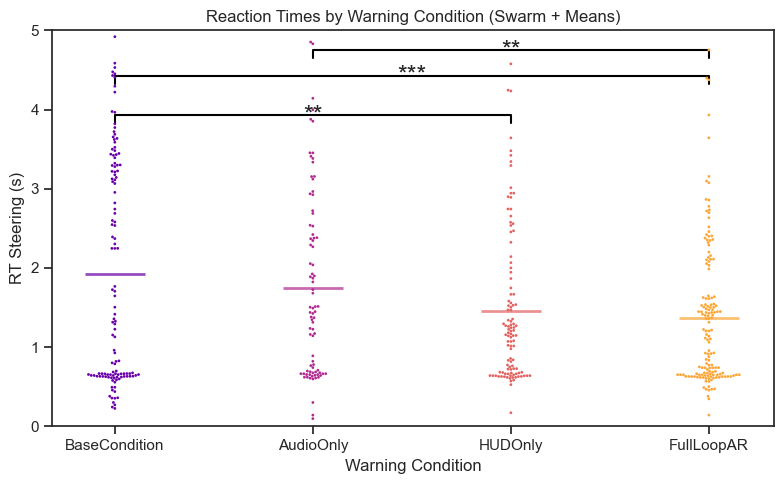

In [6]:
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf
import numpy as np

# === USER INPUT ===
DATA_FILE = r"C:\Users\erene\OneDrive\Desktop\fpca-takeOverRequests\reaction_times.csv"
EXCLUDE_UIDS = []

# Fixed event order
event_order = [
    'StagEventNew', 
    'FallingRocksEventNew',  
    'MotorcyclistEvent'
]

# === LOAD DATA ===
df = pd.read_csv(DATA_FILE)

# Sanity check
required_cols = [
    "uid", "EventName", "RT_Steering",
    "RT_fastest_type", "RT_expected_type", "RT_expected"
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Exclude UIDs if requested
if EXCLUDE_UIDS:
    df = df[~df["uid"].isin(EXCLUDE_UIDS)]
    print(f"Excluded {len(EXCLUDE_UIDS)} UIDs: {EXCLUDE_UIDS}")

# Restrict to only desired events
df = df[df["EventName"].isin(event_order)]

# Remove RT_Steering values above 5 seconds
df = df[df['RT_Steering'] <= 5].copy()

if df.empty:
    raise ValueError("No matching events found in data for the specified event_order.")

# === COMPUTE SUMMARY PER EVENT ===
summary = []

for event_name, subdf in df.groupby("EventName"):
    # RT_Steering stats
    mean_rt_steering = subdf["RT_Steering"].mean(skipna=True)
    median_rt_steering = subdf["RT_Steering"].median(skipna=True)
    sd_rt_steering = subdf["RT_Steering"].std(skipna=True)
    n_valid = subdf["RT_Steering"].notna().sum()

    # RT_expected stats
    mean_rt_expected = subdf["RT_expected"].mean(skipna=True)
    median_rt_expected = subdf["RT_expected"].median(skipna=True)
    sd_rt_expected = subdf["RT_expected"].std(skipna=True)

    # Fastest type counts and most frequent
    fastest_counts = subdf["RT_fastest_type"].value_counts(dropna=True)
    most_common_fastest = fastest_counts.idxmax() if not fastest_counts.empty else None
    n_fastest_types = {k: int(v) for k, v in fastest_counts.items()}

    # Expected type counts and most frequent
    expected_counts = subdf["RT_expected_type"].value_counts(dropna=True)
    most_common_expected = expected_counts.idxmax() if not expected_counts.empty else None
    n_expected_types = {k: int(v) for k, v in expected_counts.items()}

    summary.append({
        "Event": event_name,
        "Mean_RT_Steering": mean_rt_steering,
        "Median_RT_Steering": median_rt_steering,
        "SD_RT_Steering": sd_rt_steering,
        "n_valid": n_valid,
        "Mean_RT_Expected": mean_rt_expected,
        "Median_RT_Expected": median_rt_expected,
        "SD_RT_Expected": sd_rt_expected,
        "Most_Common_RT_Fastest_Type": most_common_fastest,
        "Fastest_Type_Counts": n_fastest_types,
        "Most_Common_RT_Expected_Type": most_common_expected,
        "Expected_Type_Counts": n_expected_types
    })

# === SAVE & DISPLAY SUMMARY ===
summary_df = pd.DataFrame(summary)

# Keep only rows in event_order and sort by that order
summary_df["Event"] = pd.Categorical(summary_df["Event"], categories=event_order, ordered=True)
summary_df = summary_df.sort_values("Event")

pd.set_option('display.max_colwidth', None)
print("\n=== Reaction Time Summary per Event ===")
print(summary_df.to_string(index=False))

# ------------------ SETUP ------------------
# Make sure ExperimentalCondition exists
if "ExperimentalCondition" not in df.columns:
    raise ValueError("Column 'ExperimentalCondition' not found in data.")

# Set condition order
cond_order = ['BaseCondition','AudioOnly', 'HUDOnly', 'FullLoopAR']

df['ExperimentalCondition'] = pd.Categorical(df['ExperimentalCondition'], categories=cond_order, ordered=True)

# ------------------ STATISTICS ------------------
# ============ CHANGED: Linear regression with clustered SE ============
print("\n=== LINEAR REGRESSION WITH CLUSTERED SE ===")
model = smf.ols("RT_Steering ~ C(ExperimentalCondition)", data=df).fit(
    cov_type='cluster',
    cov_kwds={'groups': df['uid']}  # Cluster by participant
)
print(model.summary())

# ============ CHANGED: Pairwise contrasts (not independent t-tests) ============
from itertools import combinations

pairwise_results = []
for cond1, cond2 in combinations(cond_order, 2):
    # Construct contrast vector
    contrast_vector = np.zeros(len(model.params))
    
    try:
        idx1 = model.params.index.get_loc(f"C(ExperimentalCondition)[T.{cond1}]")
        idx2 = model.params.index.get_loc(f"C(ExperimentalCondition)[T.{cond2}]")
        contrast_vector[idx1] = 1
        contrast_vector[idx2] = -1
    except KeyError:
        if cond1 == cond_order[0]:  # reference (BaseCondition)
            idx2 = model.params.index.get_loc(f"C(ExperimentalCondition)[T.{cond2}]")
            contrast_vector[idx2] = -1
        elif cond2 == cond_order[0]:
            idx1 = model.params.index.get_loc(f"C(ExperimentalCondition)[T.{cond1}]")
            contrast_vector[idx1] = 1
        else:
            continue
    
    # Test contrast
    ttest = model.t_test(contrast_vector)
    coef = ttest.effect[0]
    pval = ttest.pvalue
    
    pairwise_results.append({
        'contrast': f'{cond1} vs {cond2}',
        'coef': coef,
        'pval': pval
    })

pairwise_df = pd.DataFrame(pairwise_results)

# Holm correction
pvals = [r['pval'] for r in pairwise_results]
reject, pvals_corrected, _, _ = multipletests(pvals, method='holm')
pairwise_df['pval_holm'] = pvals_corrected
pairwise_df['significant'] = reject

print("\n=== PAIRWISE COMPARISONS (Holm-adjusted) ===")
print(pairwise_df.to_string(index=False))

# ------------------ SWARM PLOT WITH MEANS ------------------
plt.figure(figsize=(8,5))

# Swarm plot of individual RTs
sns.swarmplot(
    data=df,
    x='ExperimentalCondition',
    y='RT_Steering',
    order=cond_order,
    size=2,
    palette='plasma'
)
palette_colors = sns.color_palette('plasma', n_colors=len(cond_order))

# Overlay mean per condition as a short horizontal line
means = df.groupby('ExperimentalCondition')['RT_Steering'].mean()
ax = plt.gca()
for i, cond in enumerate(cond_order):
    y = means[cond]
    # horizontal line centered on x=i, width=0.3
    ax.hlines(y, i-0.15, i+0.15, colors=palette_colors[i] + (0.7,), linewidth=2, zorder=3)

plt.ylabel("RT Steering (s)")
plt.xlabel("Warning Condition")
plt.title("Reaction Times by Warning Condition (Swarm + Means)")
plt.ylim(0, 5)

# ------------------ SIGNIFICANCE BRACKETS ------------------
y_start = 2  # base offset above the mean
y_step = 0.5   # vertical step for stacking

cond_to_idx = {cond: i for i, cond in enumerate(cond_order)}
cond_max_level = {cond: 0 for cond in cond_order}  # max level used for each condition

for _, row in pairwise_df.iterrows():
    if row['significant']:
        cond1, cond2 = row['contrast'].split(' vs ')
        x1, x2 = cond_to_idx[cond2], cond_to_idx[cond1]

        # Determine number of stars
        p = row['pval_holm']  # use Holm-adjusted p
        if p < 0.001:
            stars = '***'
        elif p < 0.01:
            stars = '**'
        elif p < 0.05:
            stars = '*'
        else:
            stars = ''
            continue  # skip if not significant

        # Determine the level for this bracket: max of the two conditions
        level = max(cond_max_level[cond1], cond_max_level[cond2])
        cond_max_level[cond1] = level + 1
        cond_max_level[cond2] = level + 1
        
        y = max(means[cond1], means[cond2]) + y_start + level * y_step
        
        ax.plot([x1, x1, x2, x2], [y-0.1, y, y, y-0.1], lw=1.5, c='k')
        ax.text((x1 + x2)/2, y - 0.15, stars, ha='center', va='bottom', fontsize=18)

plt.tight_layout()
plt.show()

In [7]:
sanity check successful completion state in filtered df vs success_df 

SyntaxError: invalid syntax (1778832537.py, line 1)

C:\Users\erene\AppData\Local\Temp\ipykernel_19100\1978861575.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df_filtered.groupby(['EventName','ExperimentalCondition'])['RT_Steering'].mean()


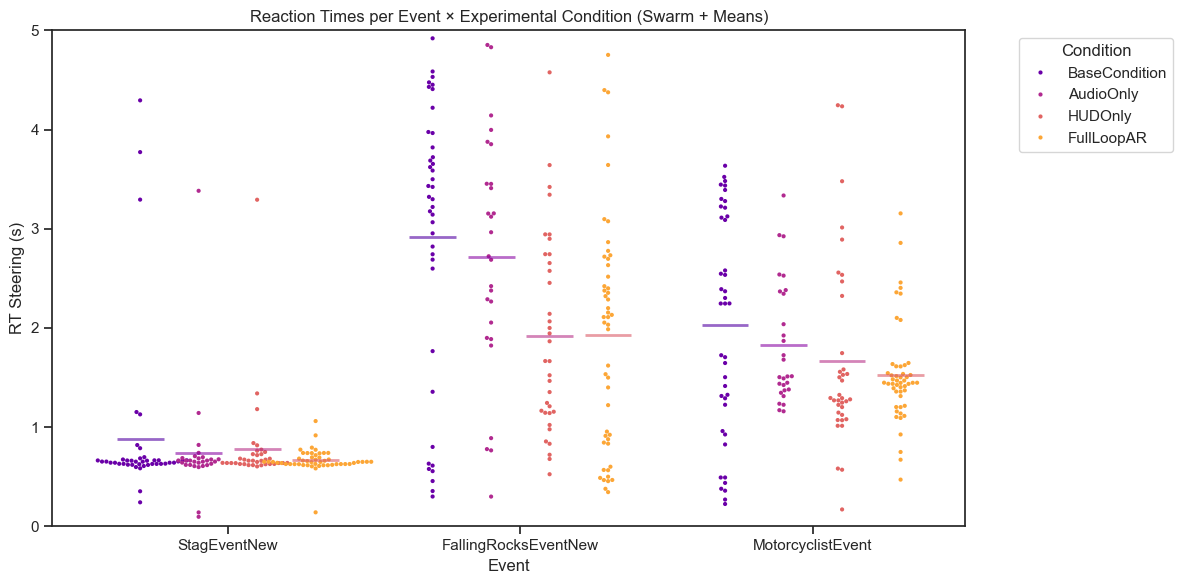

In [ ]:

# Optional: remove RT outliers above 5 s
df_filtered = df[df['RT_Steering'] <= 5].copy()

# Make ExperimentalCondition categorical
df_filtered['ExperimentalCondition'] = pd.Categorical(
    df_filtered['ExperimentalCondition'], categories=cond_order, ordered=True
)

# Make EventName categorical (fixed order)
event_order = ['StagEventNew', 'FallingRocksEventNew', 'MotorcyclistEvent']
df_filtered['EventName'] = pd.Categorical(df_filtered['EventName'], categories=event_order, ordered=True)

# ------------------ SWARM + MEAN PLOT ------------------
plt.figure(figsize=(12,6))

# Swarm plot of individual RTs per event × condition
sns.swarmplot(
    data=df_filtered,
    x='EventName',
    y='RT_Steering',
    hue='ExperimentalCondition',
    hue_order=cond_order,
    palette='plasma',
    dodge=True,   # separate conditions side-by-side
    size=3
)

# Overlay mean per event × condition as short horizontal lines
means = df_filtered.groupby(['EventName','ExperimentalCondition'])['RT_Steering'].mean()

ax = plt.gca()
for i, event in enumerate(event_order):
    for j, cond in enumerate(cond_order):
        mean_val = means.get((event, cond), np.nan)
        if not np.isnan(mean_val):
            # dodge=True separates conditions by ~0.2 per hue, calculate x positions
            x = i + (j - 1.5)*0.2  # centers 4 conditions around each event
            ax.hlines(mean_val, x-0.08, x+0.08, colors=sns.color_palette('plasma')[j], linewidth=2, zorder=3, alpha=0.6)

plt.ylabel("RT Steering (s)")
plt.xlabel("Event")
plt.title("Reaction Times per Event × Experimental Condition (Swarm + Means)")
plt.ylim(0,5)
plt.legend(title='Condition', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:

# # ------------------ PAIRWISE T-TESTS FOR ANOVA ------------------
# pairwise_results = []

# for cond1, cond2 in combinations(cond_order, 2):
#     data1 = df.loc[df['ExperimentalCondition'] == cond1, 'RT_Steering'].dropna()
#     data2 = df.loc[df['ExperimentalCondition'] == cond2, 'RT_Steering'].dropna()
    
#     # Two-sample t-test
#     t_stat, p_val, _ = sm.stats.ttest_ind(data1, data2)
    
#     pairwise_results.append({
#         'contrast': f'{cond2} vs {cond1}',
#         't_stat': t_stat,
#         'pval': p_val
#     })

# pairwise_df = pd.DataFrame(pairwise_results)

# # Holm correction
# reject, pvals_corrected, _, _ = multipletests(pairwise_df['pval'], method='holm')
# pairwise_df['pval_holm'] = pvals_corrected
# pairwise_df['significant'] = reject

# # ------------------ FORMAT TABLE ------------------
# pairwise_display = pairwise_df.copy()
# pairwise_display['t_stat'] = pairwise_display['t_stat'].map(lambda x: f"{x:.3f}")
# pairwise_display['pval'] = pairwise_display['pval'].map(lambda x: f"{x:.3f}")
# pairwise_display['pval_holm'] = pairwise_display['pval_holm'].map(lambda x: f"{x:.3f}")

# # ------------------ TABLE FIGURE ------------------
# fig, ax = plt.subplots(figsize=(8,4))
# ax.axis('off')

# table = ax.table(
#     cellText=pairwise_display[['contrast', 't_stat', 'pval', 'pval_holm', 'significant']].values,
#     colLabels=['Contrast', 't-stat', 'p-value', 'Holm-adjusted p', 'Significant?'],
#     cellLoc='center',
#     loc='center'
# )

# # Font size
# table.auto_set_font_size(False)
# table.set_fontsize(10)

# # Manually set column widths and heights
# for key in table.get_celld().keys():
#     cell = table.get_celld()[key]
#     cell.set_width(0.5)
#     cell.set_height(0.15)

# plt.title("Pairwise ANOVA Comparisons (Holm-adjusted)",pad=10)
# plt.tight_layout()
# plt.show()


C:\Users\erene\AppData\Local\Temp\ipykernel_19840\3850818520.py:75: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


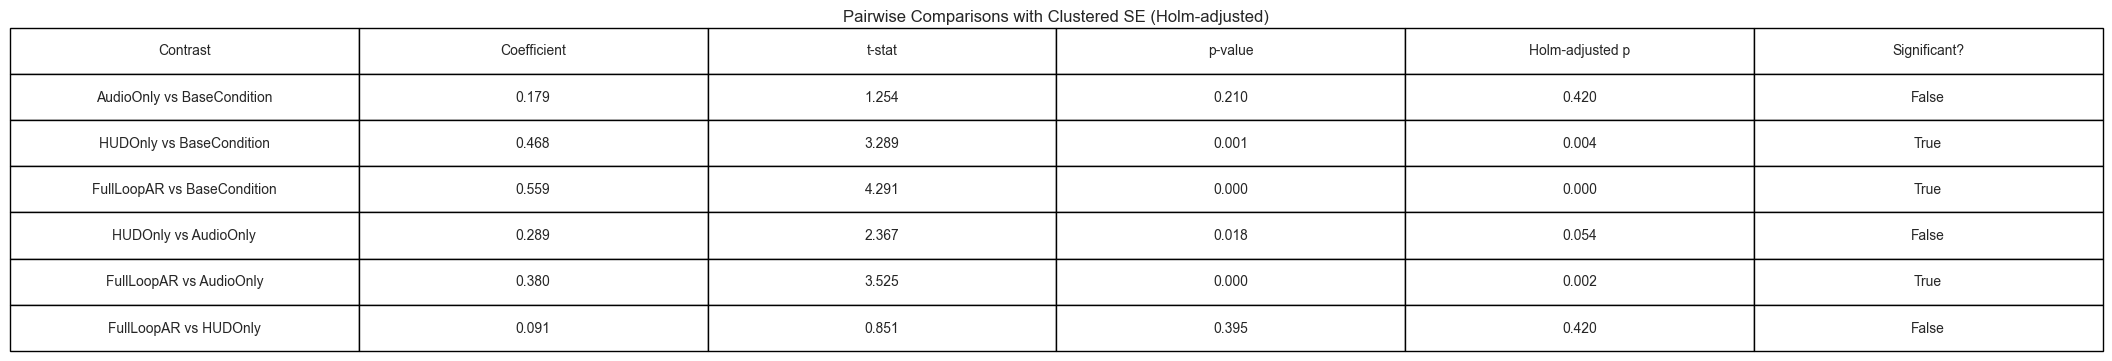

In [ ]:
# ------------------ PAIRWISE COMPARISONS WITH CLUSTERED SE ------------------
import numpy as np
from itertools import combinations

pairwise_results = []
for cond1, cond2 in combinations(cond_order, 2):
    # Construct contrast vector
    contrast_vector = np.zeros(len(model.params))
    
    try:
        # Both conditions are non-reference
        idx1 = model.params.index.get_loc(f"C(ExperimentalCondition)[T.{cond1}]")
        idx2 = model.params.index.get_loc(f"C(ExperimentalCondition)[T.{cond2}]")
        contrast_vector[idx1] = 1
        contrast_vector[idx2] = -1
    except KeyError:
        # One condition is the reference (BaseCondition)
        if cond1 == cond_order[0]:  # cond1 is reference
            idx2 = model.params.index.get_loc(f"C(ExperimentalCondition)[T.{cond2}]")
            contrast_vector[idx2] = -1
        elif cond2 == cond_order[0]:  # cond2 is reference
            idx1 = model.params.index.get_loc(f"C(ExperimentalCondition)[T.{cond1}]")
            contrast_vector[idx1] = 1
        else:
            continue
    
    # Test contrast (uses clustered SE automatically)
    ttest = model.t_test(contrast_vector)
    coef = ttest.effect[0]
    t_stat = ttest.tvalue[0][0]
    pval = ttest.pvalue
    
    pairwise_results.append({
        'contrast': f'{cond2} vs {cond1}',
        'coef': coef,
        't_stat': t_stat,
        'pval': pval
    })

pairwise_df = pd.DataFrame(pairwise_results)

# Holm correction
reject, pvals_corrected, _, _ = multipletests(pairwise_df['pval'], method='holm')
pairwise_df['pval_holm'] = pvals_corrected
pairwise_df['significant'] = reject

# ------------------ FORMAT TABLE ------------------
pairwise_display = pairwise_df.copy()
pairwise_display['coef'] = pairwise_display['coef'].map(lambda x: f"{x:.3f}")
pairwise_display['t_stat'] = pairwise_display['t_stat'].map(lambda x: f"{x:.3f}")
pairwise_display['pval'] = pairwise_display['pval'].map(lambda x: f"{x:.3f}")
pairwise_display['pval_holm'] = pairwise_display['pval_holm'].map(lambda x: f"{x:.3f}")

# ------------------ TABLE FIGURE ------------------
fig, ax = plt.subplots(figsize=(9, 4))
ax.axis('off')
table = ax.table(
    cellText=pairwise_display[['contrast', 'coef', 't_stat', 'pval', 'pval_holm', 'significant']].values,
    colLabels=['Contrast', 'Coefficient', 't-stat', 'p-value', 'Holm-adjusted p', 'Significant?'],
    cellLoc='center',
    loc='center'
)

# Font size
table.auto_set_font_size(False)
table.set_fontsize(10)

# Manually set column widths and heights
for key in table.get_celld().keys():
    cell = table.get_celld()[key]
    cell.set_width(0.5)
    cell.set_height(0.15)

plt.title("Pairwise Comparisons with Clustered SE (Holm-adjusted)", pad=10)
plt.tight_layout()
plt.show()

In [ ]:
# Convert float to category 0, 1
df_filtered['SuccessfulCompletionState'] = df_filtered['SuccessfulCompletionState'].astype(int).astype('category')
df_filtered['SuccessfulCompletionState']

0       0
1       0
12      1
13      0
20      0
       ..
1861    1
1868    0
1872    1
1873    1
1880    0
Name: SuccessfulCompletionState, Length: 461, dtype: category
Categories (2, int32): [0, 1]

# success * RT (1Wanova)

In [ ]:
# # === USER INPUT ===
# DATA_FILE = r"C:\Users\erene\OneDrive\Desktop\fpca-takeOverRequests\reaction_times.csv"   # path to your CSV file
# EXCLUDE_UIDS = []     # <- enter UIDs you want to exclude, or leave empty []

# # Fixed success state order
# success_order = [0.0, 1.0]

# # === LOAD DATA ===
# df = pd.read_csv(DATA_FILE)

# # Sanity check
# required_cols = [
#     "uid", "SuccessfulCompletionState", "RT_Steering",
#     "RT_fastest_type", "RT_expected_type", "RT_expected"
# ]
# missing = [c for c in required_cols if c not in df.columns]
# if missing:
#     raise ValueError(f"Missing columns: {missing}")

# # Exclude UIDs if requested
# if EXCLUDE_UIDS:
#     df = df[~df["uid"].isin(EXCLUDE_UIDS)]
#     print(f"Excluded {len(EXCLUDE_UIDS)} UIDs: {EXCLUDE_UIDS}")

# # Remove RT_Steering values above 5 seconds
# df = df[df['RT_Steering'] <= 5].copy()

# # Convert SuccessfulCompletionState to integer categories
# df['SuccessfulCompletionState'] = df['SuccessfulCompletionState'].astype(int)

# if df.empty:
#     raise ValueError("No matching SuccessfulCompletionState found in data.")

# # === COMPUTE SUMMARY PER SUCCESS STATE ===
# summary = []

# for success_state, subdf in df.groupby("SuccessfulCompletionState"):
#     # RT_Steering stats
#     mean_rt_steering = subdf["RT_Steering"].mean(skipna=True)
#     median_rt_steering = subdf["RT_Steering"].median(skipna=True)
#     sd_rt_steering = subdf["RT_Steering"].std(skipna=True)
#     n_valid = subdf["RT_Steering"].notna().sum()

#     # RT_expected stats
#     mean_rt_expected = subdf["RT_expected"].mean(skipna=True)
#     median_rt_expected = subdf["RT_expected"].median(skipna=True)
#     sd_rt_expected = subdf["RT_expected"].std(skipna=True)

#     # Fastest type counts and most frequent
#     fastest_counts = subdf["RT_fastest_type"].value_counts(dropna=True)
#     most_common_fastest = fastest_counts.idxmax() if not fastest_counts.empty else None
#     n_fastest_types = {k: int(v) for k, v in fastest_counts.items()}

#     # Expected type counts and most frequent
#     expected_counts = subdf["RT_expected_type"].value_counts(dropna=True)
#     most_common_expected = expected_counts.idxmax() if not expected_counts.empty else None
#     n_expected_types = {k: int(v) for k, v in expected_counts.items()}

#     summary.append({
#         "SuccessfulCompletionState": success_state,
#         "Mean_RT_Steering": mean_rt_steering,
#         "Median_RT_Steering": median_rt_steering,
#         "SD_RT_Steering": sd_rt_steering,
#         "n_valid": n_valid,
#         "Mean_RT_Expected": mean_rt_expected,
#         "Median_RT_Expected": median_rt_expected,
#         "SD_RT_Expected": sd_rt_expected,
#         "Most_Common_RT_Fastest_Type": most_common_fastest,
#         "Fastest_Type_Counts": n_fastest_types,
#         "Most_Common_RT_Expected_Type": most_common_expected,
#         "Expected_Type_Counts": n_expected_types
#     })

# # === SAVE & DISPLAY SUMMARY ===
# summary_df = pd.DataFrame(summary)

# # Make categorical with proper order
# summary_df["SuccessfulCompletionState"] = pd.Categorical(
#     summary_df["SuccessfulCompletionState"], 
#     categories=[0, 1], 
#     ordered=True
# )
# summary_df = summary_df.sort_values("SuccessfulCompletionState")

# pd.set_option('display.max_colwidth', None)
# print("\n=== Reaction Time Summary per Success State ===")
# print(summary_df.to_string(index=False))

# # ------------------ STATISTICS ------------------
# # 1. T-test for RT_Steering by Success State
# data_fail = df.loc[df['SuccessfulCompletionState'] == 0, 'RT_Steering'].dropna()
# data_success = df.loc[df['SuccessfulCompletionState'] == 1, 'RT_Steering'].dropna()
# t_stat, p_val, _ = sm.stats.ttest_ind(data_fail, data_success)

# print(f"\n=== T-TEST: RT_Steering by Success State ===")
# print(f"Failure (0): n={len(data_fail)}, mean={data_fail.mean():.3f}, sd={data_fail.std():.3f}")
# print(f"Success (1): n={len(data_success)}, mean={data_success.mean():.3f}, sd={data_success.std():.3f}")
# print(f"t-statistic: {t_stat:.3f}")
# print(f"p-value: {p_val:.4f}")

# # ------------------ SWARM PLOT WITH MEANS ------------------
# plt.figure(figsize=(6,5))

# # Swarm plot of individual RTs
# sns.swarmplot(
#     data=df,
#     x='SuccessfulCompletionState',
#     y='RT_Steering',
#     size=2,
#     palette=["#00ff00","#ff0000" ]
# )
# palette_colors = sns.color_palette('plasma', n_colors=2)

# # Overlay mean per success state as a short horizontal line
# means = df.groupby('SuccessfulCompletionState')['RT_Steering'].mean()
# ax = plt.gca()
# for i, state in enumerate([0, 1]):
#     if state in means.index:
#         y = means[state]
#         ax.hlines(y, i-0.15, i+0.15, colors=palette_colors[i] + (0.7,), linewidth=2, zorder=3)

# plt.ylabel("RT Steering (s)")
# plt.xlabel("Successful Completion State (0=Fail, 1=Success)")
# plt.title("Reaction Times by Success State (Swarm + Means)")
# plt.ylim(0, 5)

# # Add significance bracket if p < 0.05
# if p_val < 0.05:
#     if p_val < 0.001:
#         stars = '***'
#     elif p_val < 0.01:
#         stars = '**'
#     else:
#         stars = '*'
    
#     y_max = max(means[0], means[1]) + 0.5
#     ax.plot([0, 0, 1, 1], [y_max-0.1, y_max, y_max, y_max-0.1], lw=1.5, c='k')
#     ax.text(0.5, y_max - 0.15, stars, ha='center', va='bottom', fontsize=18)

# plt.tight_layout()
# plt.show()


=== RUNNING T-TESTS PER EVENT ===

=== T-TESTS: RT by Success/Fail per Event (Holm-adjusted) ===
               event   t_stat     pval  n_fail  n_success  mean_fail  mean_success  pval_holm  significant
FallingRocksEventNew 0.305186 0.760650      72         79   2.365408      2.301878   0.760650        False
   MotorcyclistEvent 3.758015 0.000243      72         83   2.008295      1.518365   0.000729         True
        StagEventNew 1.729049 0.085817      80         75   0.835900      0.685520   0.171635        False


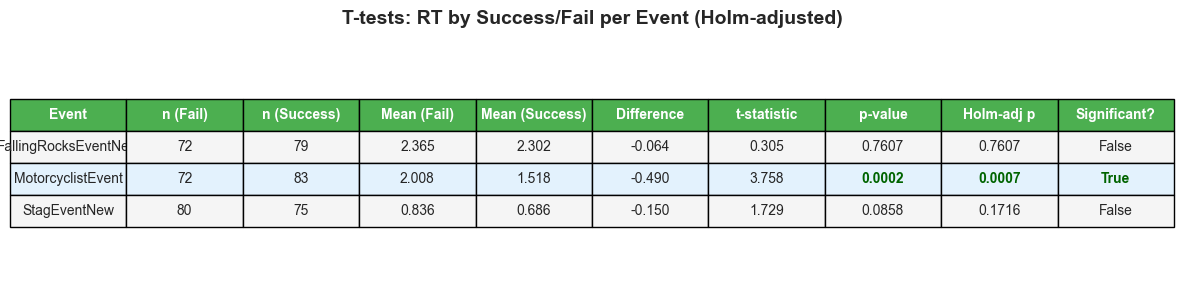

C:\Users\erene\AppData\Local\Temp\ipykernel_11168\1980844098.py:142: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df_events.groupby(['EventName', 'SuccessfulCompletionState'])['RT_Steering'].mean()


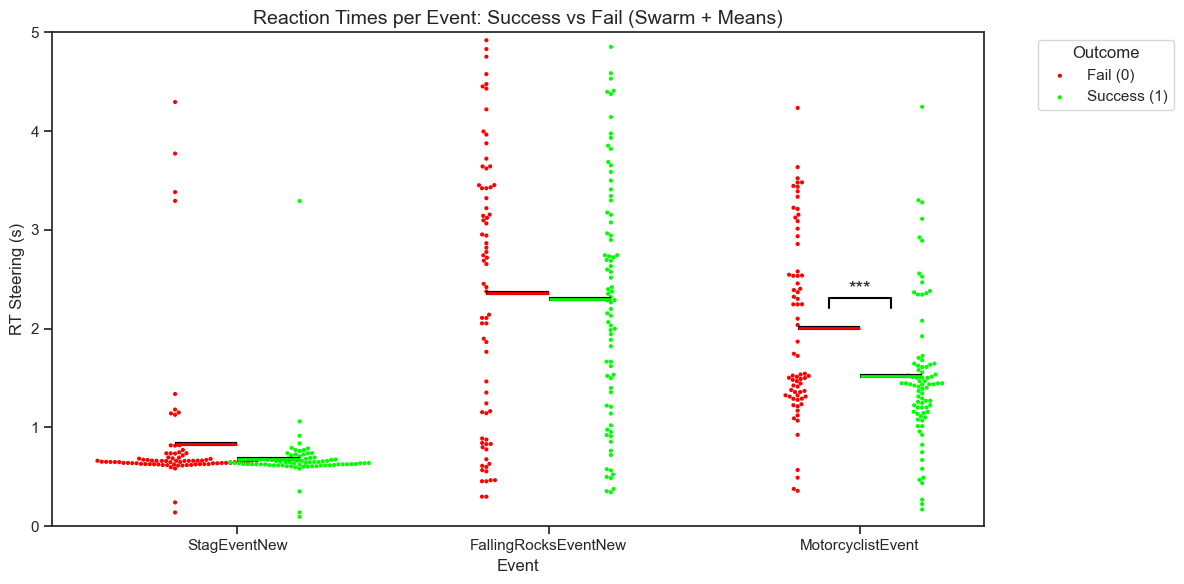

In [ ]:
# ------------------ SWARM PLOT: RT per Event by Success/Fail ------------------
# Load data
DATA_FILE = r"C:\Users\erene\OneDrive\Desktop\fpca-takeOverRequests\reaction_times.csv"
df = pd.read_csv(DATA_FILE)

# Remove RT_Steering values above 5 seconds
df = df[df['RT_Steering'] <= 5].copy()

# Convert SuccessfulCompletionState to integer
df['SuccessfulCompletionState'] = df['SuccessfulCompletionState'].astype(int)

# Fixed event order
event_order = ['StagEventNew', 'FallingRocksEventNew', 'MotorcyclistEvent']

# Filter to only desired events
df_events = df[df['EventName'].isin(event_order)].copy()

# Use alphabetical event order
event_order_alpha = sorted(event_order)

# Make EventName categorical
df_events['EventName'] = pd.Categorical(
    df_events['EventName'],
    categories=event_order,
    ordered=True
)

df_events['SuccessfulCompletionState'] = pd.Categorical(
    df_events['SuccessfulCompletionState'],
    categories=[0, 1],
    ordered=True
)

# ------------------ T-TESTS PER EVENT ------------------
print("\n=== RUNNING T-TESTS PER EVENT ===")
event_ttest_results = []

for event in event_order_alpha:
    df_event = df_events[df_events['EventName'] == event]
    data_fail = df_event.loc[df_event['SuccessfulCompletionState'] == 0, 'RT_Steering'].dropna()
    data_success = df_event.loc[df_event['SuccessfulCompletionState'] == 1, 'RT_Steering'].dropna()
    
    if len(data_fail) > 0 and len(data_success) > 0:
        # Two-sample t-test
        t_stat, p_val, _ = sm.stats.ttest_ind(data_fail, data_success)
        
        event_ttest_results.append({
            'event': event,
            't_stat': t_stat,
            'pval': p_val,
            'n_fail': len(data_fail),
            'n_success': len(data_success),
            'mean_fail': data_fail.mean(),
            'mean_success': data_success.mean()
        })

event_ttest_df = pd.DataFrame(event_ttest_results)

# Holm correction across all events
reject, pvals_corrected, _, _ = multipletests(event_ttest_df['pval'], method='holm')
event_ttest_df['pval_holm'] = pvals_corrected
event_ttest_df['significant'] = reject

print("\n=== T-TESTS: RT by Success/Fail per Event (Holm-adjusted) ===")
print(event_ttest_df.to_string(index=False))

# ------------------ FORMAT TABLE ------------------
event_display = event_ttest_df.copy()
event_display['t_stat'] = event_display['t_stat'].map(lambda x: f"{x:.3f}")
event_display['mean_fail'] = event_display['mean_fail'].map(lambda x: f"{x:.3f}")
event_display['mean_success'] = event_display['mean_success'].map(lambda x: f"{x:.3f}")
event_display['pval'] = event_display['pval'].map(lambda x: f"{x:.4f}")
event_display['pval_holm'] = event_display['pval_holm'].map(lambda x: f"{x:.4f}")

# Calculate difference for display
event_ttest_df['difference'] = event_ttest_df['mean_success'] - event_ttest_df['mean_fail']
event_display['difference'] = event_ttest_df['difference'].map(lambda x: f"{x:.3f}")

# ------------------ TABLE FIGURE ------------------
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')

table = ax.table(
    cellText=event_display[['event', 'n_fail', 'n_success', 'mean_fail', 'mean_success', 
                            'difference', 't_stat', 'pval', 'pval_holm', 'significant']].values,
    colLabels=['Event', 'n (Fail)', 'n (Success)', 'Mean (Fail)', 'Mean (Success)', 
               'Difference', 't-statistic', 'p-value', 'Holm-adj p', 'Significant?'],
    cellLoc='center',
    loc='center'
)

# Font size and styling
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.0)

# Color header row
for i in range(10):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Color data rows by significance
for i, row in enumerate(event_ttest_df.itertuples(), start=1):
    if row.significant:
        row_color = '#E3F2FD'  # Light blue for significant
    else:
        row_color = '#F5F5F5'  # Light gray for non-significant
    
    for j in range(10):
        table[(i, j)].set_facecolor(row_color)
    
    # Bold p-values if significant
    if row.significant:
        table[(i, 7)].set_text_props(weight='bold', color='darkgreen')  # p-value
        table[(i, 8)].set_text_props(weight='bold', color='darkgreen')  # holm-adj p
        table[(i, 9)].set_text_props(weight='bold', color='darkgreen')  # significant

plt.title("T-tests: RT by Success/Fail per Event (Holm-adjusted)", 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# ------------------ SWARM PLOT WITH MEANS ------------------
plt.figure(figsize=(12, 6))

# Get palette colors
palette_colors = sns.color_palette('plasma', n_colors=2)

# Swarm plot of individual RTs per event × success state
sns.swarmplot(
    data=df_events,
    x='EventName',
    y='RT_Steering',
    hue='SuccessfulCompletionState',
    hue_order=[0, 1],
    palette=["#ff0000", "#00ff00"],
    dodge=True,
    size=3
)

# Overlay mean per event × success state as short horizontal lines
means = df_events.groupby(['EventName', 'SuccessfulCompletionState'])['RT_Steering'].mean()

ax = plt.gca()

for i, event in enumerate(event_order):  # ← Use event_order, not event_order_alpha
    for j, state in enumerate([0, 1]):
        mean_val = means.get((event, state), np.nan)
        if not np.isnan(mean_val):
            # dodge=True separates hues by ~0.2
            x = i + (j - 0.5) * 0.2
            
            # Draw black outline first
            ax.hlines(mean_val, x-0.1, x+0.1, colors='black', linewidth=3, zorder=10)
            
            # Draw colored line on top
            ax.hlines(mean_val, x-0.1, x+0.1, colors=["#ff0000", "#00ff00"][j], 
                     linewidth=2, zorder=11, alpha=1)

# Add significance brackets
for idx, row in event_ttest_df.iterrows():
    event = row['event']
    event_idx = event_order.index(event)  # ← FIXED: Use event_order instead of event_order_alpha
    
    if row['significant']:
        # Determine number of stars
        p = row['pval_holm']
        if p < 0.001:
            stars = '***'
        elif p < 0.01:
            stars = '**'
        elif p < 0.05:
            stars = '*'
        else:
            stars = ''
            continue
        
        # Get max mean for this event
        y_bracket = max(row['mean_fail'], row['mean_success']) + 0.3
        
        # Draw bracket
        x1 = event_idx - 0.1
        x2 = event_idx + 0.1
        ax.plot([x1, x1, x2, x2], [y_bracket-0.1, y_bracket, y_bracket, y_bracket-0.1], 
               lw=1.5, c='k')
        ax.text((x1 + x2)/2, y_bracket, stars, ha='center', va='bottom', fontsize=14)

plt.ylabel("RT Steering (s)", fontsize=12)
plt.xlabel("Event", fontsize=12)
plt.title("Reaction Times per Event: Success vs Fail (Swarm + Means)", 
         fontsize=14)
plt.ylim(0, 5)
plt.legend(title='Outcome', labels=['Fail (0)', 'Success (1)'], 
          bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# LOG TRANSFORM FOR REACTION TIME


=== RUNNING MEDIAN-RT ANALYSIS PER EVENT (Mann–Whitney U) ===

=== MEDIAN-RT RESULTS (Holm-adjusted) ===
               event  t_stat     pval  n_fail  n_success  mean_fail_raw  mean_success_raw   pct_diff  pval_holm  significant
FallingRocksEventNew  2935.0 0.735995      72         79       2.554093          2.288772 -10.388076   0.735995        False
   MotorcyclistEvent  3904.0 0.001021      72         83       1.634438          1.436932 -12.084019   0.003064         True
        StagEventNew  3561.0 0.044759      80         75       0.656822          0.640287  -2.517394   0.089518        False


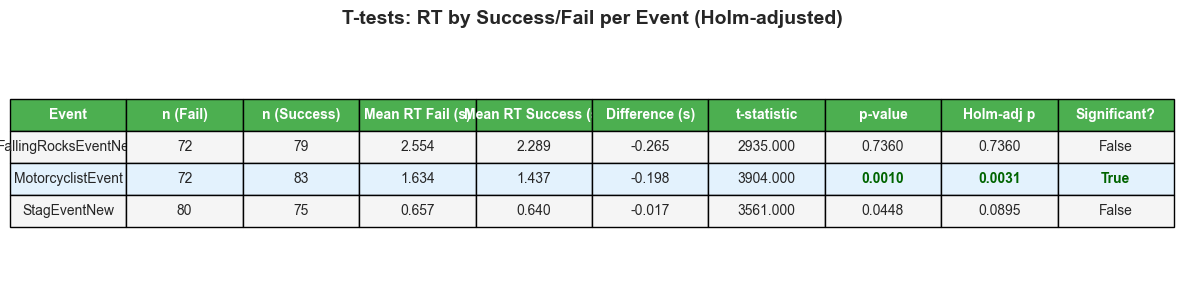

C:\Users\erene\AppData\Local\Temp\ipykernel_11168\440043045.py:170: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df_events.groupby(['EventName', 'SuccessfulCompletionState'])['RT_Steering'].mean()


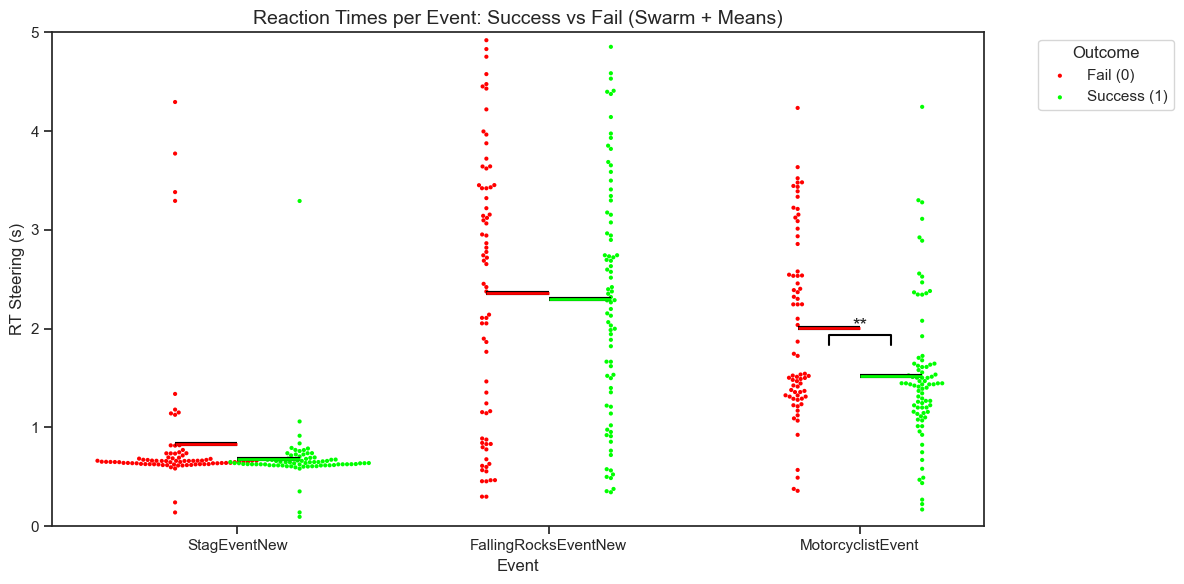

In [ ]:
# ------------------ SWARM PLOT: RT per Event by Success/Fail ------------------
# Load data
DATA_FILE = r"C:\Users\erene\OneDrive\Desktop\fpca-takeOverRequests\reaction_times.csv"
df = pd.read_csv(DATA_FILE)

# Remove RT_Steering values above 5 seconds
df = df[df['RT_Steering'] <= 5].copy()

# Convert SuccessfulCompletionState to integer
df['SuccessfulCompletionState'] = df['SuccessfulCompletionState'].astype(int)

# Fixed event order
event_order = ['StagEventNew', 'FallingRocksEventNew', 'MotorcyclistEvent']

# Filter to only desired events
df_events = df[df['EventName'].isin(event_order)].copy()

# Use alphabetical event order
event_order_alpha = sorted(event_order)

# Make EventName categorical
df_events['EventName'] = pd.Categorical(
    df_events['EventName'],
    categories=event_order,
    ordered=True
)

df_events['SuccessfulCompletionState'] = pd.Categorical(
    df_events['SuccessfulCompletionState'],
    categories=[0, 1],
    ordered=True
)

# ------------------ MEDIAN-BASED ANALYSIS PER EVENT (Mann–Whitney U) ------------------
print("\n=== RUNNING MEDIAN-RT ANALYSIS PER EVENT (Mann–Whitney U) ===")

from scipy.stats import mannwhitneyu

event_results = []

for event in event_order_alpha:
    df_event = df_events[df_events['EventName'] == event]

    rt_fail = df_event.loc[df_event['SuccessfulCompletionState'] == 0, 'RT_Steering'].dropna()
    rt_success = df_event.loc[df_event['SuccessfulCompletionState'] == 1, 'RT_Steering'].dropna()

    if len(rt_fail) > 1 and len(rt_success) > 1:
        # Mann–Whitney U test (nonparametric, median-based)
        stat, p_val = mannwhitneyu(rt_fail, rt_success, alternative='two-sided')

        # For compatibility with your plotting code:
        # treat "t_stat" as the U statistic
        t_stat = stat

        # Use medians for interpretability
        median_fail = rt_fail.median()
        median_success = rt_success.median()

        # Percent difference for table (same field name)
        if median_fail > 0:
            pct_diff = (median_success - median_fail) / median_fail * 100
        else:
            pct_diff = np.nan

        event_results.append({
            'event': event,
            't_stat': t_stat,
            'pval': p_val,
            'n_fail': len(rt_fail),
            'n_success': len(rt_success),
            'mean_fail_raw': median_fail,        # reusing column name for compatibility
            'mean_success_raw': median_success,  # reusing column name for compatibility
            'pct_diff': pct_diff
        })

event_rtlog_df = pd.DataFrame(event_results)

# Holm correction across events
reject, pvals_corrected, _, _ = multipletests(event_rtlog_df['pval'], method='holm')
event_rtlog_df['pval_holm'] = pvals_corrected
event_rtlog_df['significant'] = reject

print("\n=== MEDIAN-RT RESULTS (Holm-adjusted) ===")
print(event_rtlog_df.to_string(index=False))

# Add difference column (required by later table code)
event_rtlog_df['difference'] = event_rtlog_df['mean_success_raw'] - event_rtlog_df['mean_fail_raw']


# ------------------ FORMAT TABLE ------------------
event_display = event_rtlog_df.copy()
event_display['t_stat'] = event_display['t_stat'].map(lambda x: f"{x:.3f}")
event_display['mean_fail_raw'] = event_display['mean_fail_raw'].map(lambda x: f"{x:.3f}")
event_display['mean_success_raw'] = event_display['mean_success_raw'].map(lambda x: f"{x:.3f}")
event_display['pval'] = event_display['pval'].map(lambda x: f"{x:.4f}")
event_display['pval_holm'] = event_display['pval_holm'].map(lambda x: f"{x:.4f}")

# Calculate difference for display
event_rtlog_df['difference'] = event_rtlog_df['mean_success_raw'] - event_rtlog_df['mean_fail_raw']
event_display['difference'] = event_rtlog_df['difference'].map(lambda x: f"{x:.3f}")

# ------------------ TABLE FIGURE ------------------
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')

table = ax.table(
    cellText=event_display[['event', 'n_fail', 'n_success', 
                            'mean_fail_raw', 'mean_success_raw', 
                            'difference', 't_stat', 'pval', 'pval_holm', 'significant']].values,

    colLabels=['Event', 'n (Fail)', 'n (Success)', 
            'Mean RT Fail (s)', 'Mean RT Success (s)', 
            'Difference (s)', 't-statistic', 'p-value', 
            'Holm-adj p', 'Significant?'],

    cellLoc='center',
    loc='center'
)

# Font size and styling
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.0)

# Color header row
for i in range(10):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Color data rows by significance
for i, row in enumerate(event_rtlog_df.itertuples(), start=1):
    if row.significant:
        row_color = '#E3F2FD'  # Light blue for significant
    else:
        row_color = '#F5F5F5'  # Light gray for non-significant
    
    for j in range(10):
        table[(i, j)].set_facecolor(row_color)
    
    # Bold p-values if significant
    if row.significant:
        table[(i, 7)].set_text_props(weight='bold', color='darkgreen')  # p-value
        table[(i, 8)].set_text_props(weight='bold', color='darkgreen')  # holm-adj p
        table[(i, 9)].set_text_props(weight='bold', color='darkgreen')  # significant

plt.title("T-tests: RT by Success/Fail per Event (Holm-adjusted)", 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# ------------------ SWARM PLOT WITH MEANS ------------------
plt.figure(figsize=(12, 6))

# Get palette colors
palette_colors = sns.color_palette('plasma', n_colors=2)

# Swarm plot of individual RTs per event × success state
sns.swarmplot(
    data=df_events,
    x='EventName',
    y='RT_Steering',
    hue='SuccessfulCompletionState',
    hue_order=[0, 1],
    palette=["#ff0000", "#00ff00"],
    dodge=True,
    size=3
)

# Overlay mean per event × success state as short horizontal lines
means = df_events.groupby(['EventName', 'SuccessfulCompletionState'])['RT_Steering'].mean()

ax = plt.gca()

for i, event in enumerate(event_order):  # ← Use event_order, not event_order_alpha
    for j, state in enumerate([0, 1]):
        mean_val = means.get((event, state), np.nan)
        if not np.isnan(mean_val):
            # dodge=True separates hues by ~0.2
            x = i + (j - 0.5) * 0.2
            
            # Draw black outline first
            ax.hlines(mean_val, x-0.1, x+0.1, colors='black', linewidth=3, zorder=10)
            
            # Draw colored line on top
            ax.hlines(mean_val, x-0.1, x+0.1, colors=["#ff0000", "#00ff00"][j], 
                     linewidth=2, zorder=11, alpha=1)

# Add significance brackets
for idx, row in event_rtlog_df.iterrows():
    event = row['event']
    event_idx = event_order.index(event)  # ← FIXED: Use event_order instead of event_order_alpha
    
    if row['significant']:
        # Determine number of stars
        p = row['pval_holm']
        if p < 0.001:
            stars = '***'
        elif p < 0.01:
            stars = '**'
        elif p < 0.05:
            stars = '*'
        else:
            stars = ''
            continue
        
        # Get max mean for this event
        y_bracket = max(row['mean_fail_raw'], row['mean_success_raw']) + 0.3
        
        # Draw bracket
        x1 = event_idx - 0.1
        x2 = event_idx + 0.1
        ax.plot([x1, x1, x2, x2], [y_bracket-0.1, y_bracket, y_bracket, y_bracket-0.1], 
               lw=1.5, c='k')
        ax.text((x1 + x2)/2, y_bracket, stars, ha='center', va='bottom', fontsize=14)

plt.ylabel("RT Steering (s)", fontsize=12)
plt.xlabel("Event", fontsize=12)
plt.title("Reaction Times per Event: Success vs Fail (Swarm + Means)", 
         fontsize=14)
plt.ylim(0, 5)
plt.legend(title='Outcome', labels=['Fail (0)', 'Success (1)'], 
          bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


=== Reaction Time Summary per Success State ===
SuccessfulCompletionState  Mean_RT_Steering  Median_RT_Steering  SD_RT_Steering  n_valid  Mean_RT_Expected  Median_RT_Expected  SD_RT_Expected Most_Common_RT_Fastest_Type                                          Fastest_Type_Counts Most_Common_RT_Expected_Type                                         Expected_Type_Counts
                        0          1.919216            1.489626        1.324992      626          2.501515            2.245844        1.729801                 RT_Steering  {'RT_Steering': 508, 'RT_Brake': 90, 'RT_Acceleration': 28}                  RT_Steering {'RT_Steering': 311, 'RT_Brake': 292, 'RT_Acceleration': 22}
                        1          1.500266            1.231485        1.036880     1127          2.054915            1.584811        1.534259                 RT_Steering {'RT_Steering': 810, 'RT_Brake': 282, 'RT_Acceleration': 35}                     RT_Brake {'RT_Brake': 587, 'RT_Steering': 527, 'RT_Acce

C:\Users\erene\AppData\Local\Temp\ipykernel_19840\1052890784.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


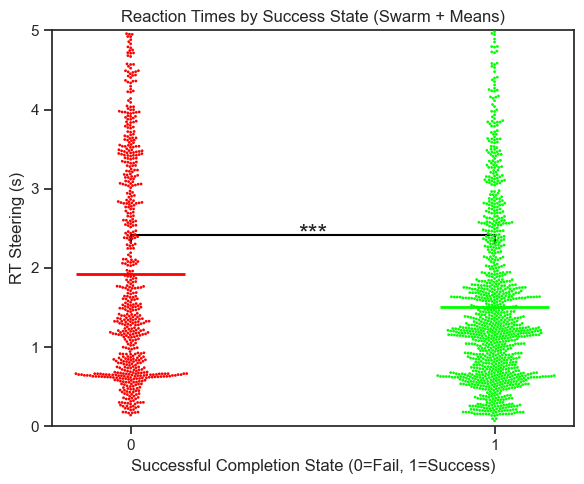

In [ ]:
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
pal = ["#ff0000" ,"#00ff00"]
# === USER INPUT ===
DATA_FILE = r"C:\Users\erene\OneDrive\Desktop\fpca-takeOverRequests\reaction_times.csv"
EXCLUDE_UIDS = []

# Fixed success state order
success_order = [0.0, 1.0]

# === LOAD DATA ===
df = pd.read_csv(DATA_FILE)

# Sanity check
required_cols = [
    "uid", "SuccessfulCompletionState", "RT_Steering",
    "RT_fastest_type", "RT_expected_type", "RT_expected"
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Exclude UIDs if requested
if EXCLUDE_UIDS:
    df = df[~df["uid"].isin(EXCLUDE_UIDS)]
    print(f"Excluded {len(EXCLUDE_UIDS)} UIDs: {EXCLUDE_UIDS}")

# Remove RT_Steering values above 5 seconds
df = df[df['RT_Steering'] <= 5].copy()

# Convert SuccessfulCompletionState to integer categories
df['SuccessfulCompletionState'] = df['SuccessfulCompletionState'].astype(int)

if df.empty:
    raise ValueError("No matching SuccessfulCompletionState found in data.")

# === COMPUTE SUMMARY PER SUCCESS STATE ===
summary = []

for success_state, subdf in df.groupby("SuccessfulCompletionState"):
    # RT_Steering stats
    mean_rt_steering = subdf["RT_Steering"].mean(skipna=True)
    median_rt_steering = subdf["RT_Steering"].median(skipna=True)
    sd_rt_steering = subdf["RT_Steering"].std(skipna=True)
    n_valid = subdf["RT_Steering"].notna().sum()

    # RT_expected stats
    mean_rt_expected = subdf["RT_expected"].mean(skipna=True)
    median_rt_expected = subdf["RT_expected"].median(skipna=True)
    sd_rt_expected = subdf["RT_expected"].std(skipna=True)

    # Fastest type counts and most frequent
    fastest_counts = subdf["RT_fastest_type"].value_counts(dropna=True)
    most_common_fastest = fastest_counts.idxmax() if not fastest_counts.empty else None
    n_fastest_types = {k: int(v) for k, v in fastest_counts.items()}

    # Expected type counts and most frequent
    expected_counts = subdf["RT_expected_type"].value_counts(dropna=True)
    most_common_expected = expected_counts.idxmax() if not expected_counts.empty else None
    n_expected_types = {k: int(v) for k, v in expected_counts.items()}

    summary.append({
        "SuccessfulCompletionState": success_state,
        "Mean_RT_Steering": mean_rt_steering,
        "Median_RT_Steering": median_rt_steering,
        "SD_RT_Steering": sd_rt_steering,
        "n_valid": n_valid,
        "Mean_RT_Expected": mean_rt_expected,
        "Median_RT_Expected": median_rt_expected,
        "SD_RT_Expected": sd_rt_expected,
        "Most_Common_RT_Fastest_Type": most_common_fastest,
        "Fastest_Type_Counts": n_fastest_types,
        "Most_Common_RT_Expected_Type": most_common_expected,
        "Expected_Type_Counts": n_expected_types
    })

# === SAVE & DISPLAY SUMMARY ===
summary_df = pd.DataFrame(summary)

# Make categorical with proper order
summary_df["SuccessfulCompletionState"] = pd.Categorical(
    summary_df["SuccessfulCompletionState"], 
    categories=[0, 1], 
    ordered=True
)
summary_df = summary_df.sort_values("SuccessfulCompletionState")

pd.set_option('display.max_colwidth', None)
print("\n=== Reaction Time Summary per Success State ===")
print(summary_df.to_string(index=False))

# ------------------ STATISTICS ------------------
# Linear regression with clustered SE
model = smf.ols("RT_Steering ~ C(SuccessfulCompletionState)", data=df).fit(
    cov_type='cluster',
    cov_kwds={'groups': df['uid']}
)

intercept = model.params['Intercept']
coef_success = model.params['C(SuccessfulCompletionState)[T.1]']
t_stat = model.tvalues['C(SuccessfulCompletionState)[T.1]']
p_val = model.pvalues['C(SuccessfulCompletionState)[T.1]']

mean_fail = intercept
mean_success = intercept + coef_success
n_fail = (df['SuccessfulCompletionState'] == 0).sum()
n_success = (df['SuccessfulCompletionState'] == 1).sum()
sd_fail = df.loc[df['SuccessfulCompletionState'] == 0, 'RT_Steering'].std()
sd_success = df.loc[df['SuccessfulCompletionState'] == 1, 'RT_Steering'].std()

print(f"\n=== T-TEST: RT_Steering by Success State ===")
print(f"Failure (0): n={n_fail}, mean={mean_fail:.3f}, sd={sd_fail:.3f}")
print(f"Success (1): n={n_success}, mean={mean_success:.3f}, sd={sd_success:.3f}")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_val:.4f}")

# ------------------ SWARM PLOT WITH MEANS ------------------
plt.figure(figsize=(6,5))

# Swarm plot of individual RTs
sns.swarmplot(
    data=df,
    x='SuccessfulCompletionState',
    y='RT_Steering',
    size=2,
    palette=pal
)
palette_colors = sns.color_palette('plasma', n_colors=2)

# Overlay mean per success state as a short horizontal line
means = df.groupby('SuccessfulCompletionState')['RT_Steering'].mean()
ax = plt.gca()
for i, state in enumerate([0, 1]):
    if state in means.index:
        y = means[state]
        ax.hlines(y, i-0.15, i+0.15, colors=pal[i], linewidth=2, zorder=3)

plt.ylabel("RT Steering (s)")
plt.xlabel("Successful Completion State (0=Fail, 1=Success)")
plt.title("Reaction Times by Success State (Swarm + Means)")
plt.ylim(0, 5)

# Add significance bracket if p < 0.05
if p_val < 0.05:
    if p_val < 0.001:
        stars = '***'
    elif p_val < 0.01:
        stars = '**'
    else:
        stars = '*'
    
    y_max = max(means[0], means[1]) + 0.5
    ax.plot([0, 0, 1, 1], [y_max-0.1, y_max, y_max, y_max-0.1], lw=1.5, c='k')
    ax.text(0.5, y_max - 0.15, stars, ha='center', va='bottom', fontsize=18)

plt.tight_layout()
plt.show()

In [ ]:
# # Per-event RT × Success State analysis
# # Fixed event order
# event_order = ['StagEventNew', 'FallingRocksEventNew', 'MotorcyclistEvent']

# # Filter to only desired events
# df_events = df[df['EventName'].isin(event_order)].copy()

# # Make EventName categorical
# df_events['EventName'] = pd.Categorical(df_events['EventName'], categories=event_order, ordered=True)
# df_events['SuccessfulCompletionState'] = pd.Categorical(df_events['SuccessfulCompletionState'], categories=[0, 1], ordered=True)

# # ------------------ SWARM + MEAN PLOT ------------------
# plt.figure(figsize=(12,6))

# # Swarm plot of individual RTs per event × success state
# sns.swarmplot(
#     data=df_events,
#     x='EventName',
#     y='RT_Steering',
#     hue='SuccessfulCompletionState',
#     hue_order=[0, 1],
#     palette='plasma',
#     dodge=True,
#     size=3
# )

# # Overlay mean per event × success state as short horizontal lines
# means = df_events.groupby(['EventName','SuccessfulCompletionState'])['RT_Steering'].mean()

# ax = plt.gca()
# palette_colors = sns.color_palette('plasma', n_colors=2)
# for i, event in enumerate(event_order):
#     for j, state in enumerate([0, 1]):
#         mean_val = means.get((event, state), np.nan)
#         if not np.isnan(mean_val):
#             # dodge=True separates hues by ~0.2
#             x = i + (j - 0.5) * 0.2  # centers 2 states around each event
#             ax.hlines(mean_val, x-0.08, x+0.08, colors=palette_colors[j], linewidth=2, zorder=3, alpha=0.6)

# plt.ylabel("RT Steering (s)")
# plt.xlabel("Event")
# plt.title("Reaction Times per Event × Success State (Swarm + Means)")
# plt.ylim(0, 5)
# plt.legend(title='Success State', labels=['Fail (0)', 'Success (1)'], bbox_to_anchor=(1.05,1), loc='upper left')
# plt.tight_layout()
# plt.show()

In [ ]:
# # ------------------ SWARM PLOT: RT per Event by Success/Fail ------------------
# # Load data (same as previous cells)
# DATA_FILE = r"C:\Users\erene\OneDrive\Desktop\fpca-takeOverRequests\reaction_times.csv"
# df = pd.read_csv(DATA_FILE)

# # Remove RT_Steering values above 5 seconds
# df = df[df['RT_Steering'] <= 5].copy()

# # Convert SuccessfulCompletionState to integer
# df['SuccessfulCompletionState'] = df['SuccessfulCompletionState'].astype(int)

# # Fixed event order
# event_order = ['StagEventNew', 'FallingRocksEventNew', 'MotorcyclistEvent']

# # Filter to only desired events
# df_events = df[df['EventName'].isin(event_order)].copy()

# # Use alphabetical event order
# event_order_alpha = sorted(event_order)

# # Make EventName categorical with *custom* order
# df_events['EventName'] = pd.Categorical(
#     df_events['EventName'],
#     categories=event_order,   # <-- use your own order here
#     ordered=True
# )

# df_events['SuccessfulCompletionState'] = pd.Categorical(
#     df_events['SuccessfulCompletionState'],
#     categories=[0, 1],
#     ordered=True
# )


# # ------------------ T-TESTS PER EVENT ------------------
# event_ttest_results = []

# for event in event_order_alpha:
#     df_event = df_events[df_events['EventName'] == event]
#     data_fail = df_event.loc[df_event['SuccessfulCompletionState'] == 0, 'RT_Steering'].dropna()
#     data_success = df_event.loc[df_event['SuccessfulCompletionState'] == 1, 'RT_Steering'].dropna()
    
#     if len(data_fail) > 0 and len(data_success) > 0:
#         # Two-sample t-test
#         t_stat, p_val, _ = sm.stats.ttest_ind(data_fail, data_success)
        
#         event_ttest_results.append({
#             'event': event,
#             't_stat': t_stat,
#             'pval': p_val,
#             'n_fail': len(data_fail),
#             'n_success': len(data_success),
#             'mean_fail': data_fail.mean(),
#             'mean_success': data_success.mean()
#         })

# event_ttest_df = pd.DataFrame(event_ttest_results)

# # Holm correction across all events
# reject, pvals_corrected, _, _ = multipletests(event_ttest_df['pval'], method='holm')
# event_ttest_df['pval_holm'] = pvals_corrected
# event_ttest_df['significant'] = reject

# print("\n=== T-TESTS: RT by Success/Fail per Event (Holm-adjusted) ===")
# print(event_ttest_df.to_string(index=False))

# # ------------------ SWARM PLOT WITH MEANS ------------------
# plt.figure(figsize=(12, 6))

# # Get palette colors
# palette_colors = sns.color_palette('plasma', n_colors=2)

# # Swarm plot of individual RTs per event × success state
# sns.swarmplot(
#     data=df_events,
#     x='EventName',
#     y='RT_Steering',
#     hue='SuccessfulCompletionState',
#     hue_order=[0, 1],
#     palette= ["#00ff00","#ff0000"],
#     dodge=True,
#     size=3
# )

# # Overlay mean per event × success state as short horizontal lines
# means = df_events.groupby(['EventName', 'SuccessfulCompletionState'])['RT_Steering'].mean()

# ax = plt.gca()

# for i, event in enumerate(event_order_alpha):
#     for j, state in enumerate([0, 1]):
#         mean_val = means.get((event, state), np.nan)
#         if not np.isnan(mean_val):
#             # dodge=True separates hues by ~0.2
#             x = i + (j - 0.5) * 0.2  # centers 2 states around each event
            
#             # Draw black outline first (slightly thicker)
#             ax.hlines(mean_val, x-0.1, x+0.1, colors='black', linewidth=3, zorder=10)
            
#             # Draw colored line on top with reduced alpha
#             ax.hlines(mean_val, x-0.1, x+0.1, colors=["#00ff00","#ff0000"][j], linewidth=2, zorder=11, alpha=1)

# # Add significance brackets
# y_max = df_events['RT_Steering'].max()
# bracket_height = 0.3

# for idx, row in event_ttest_df.iterrows():
#     event = row['event']
#     event_idx = event_order_alpha.index(event)
    
#     if row['significant']:
#         # Determine number of stars
#         p = row['pval_holm']
#         if p < 0.001:
#             stars = '***'
#         elif p < 0.01:
#             stars = '**'
#         elif p < 0.05:
#             stars = '*'
#         else:
#             stars = ''
#             continue
        
#         # Get max mean for this event
#         y_bracket = max(row['mean_fail'], row['mean_success']) + 0.3
        
#         # Draw bracket
#         x1 = event_idx - 0.1  # fail position
#         x2 = event_idx + 0.1  # success position
#         ax.plot([x1, x1, x2, x2], [y_bracket-0.1, y_bracket, y_bracket, y_bracket-0.1], lw=1.5, c='k')
#         ax.text((x1 + x2)/2, y_bracket, stars, ha='center', va='bottom', fontsize=14)

# plt.ylabel("RT Steering (s)", fontsize=12)
# plt.xlabel("Event", fontsize=12)
# plt.title("Reaction Times per Event: Success vs Fail (Swarm + Means)", fontsize=14, fontweight='bold')
# plt.ylim(0, 5)
# plt.legend(title='Outcome', labels=['Fail (0)', 'Success (1)'], bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()